# XGBOOST Model Training


## Load Cleaned Data


In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Import modules
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

clean_train = pd.read_csv('data/clean_train.csv')
clean_val = pd.read_csv('data/clean_val.csv')

metadata_cols = ['Place_ID', 'Date', 'Place_ID X Date']
train_meta = clean_train[[col for col in ['Place_ID', 'Date'] if col in clean_train.columns]].copy()
val_meta = clean_val[[col for col in ['Place_ID', 'Date'] if col in clean_val.columns]].copy()
drop_cols = ['target'] + [col for col in metadata_cols if col in clean_train.columns]

X_tr = clean_train.drop(columns=drop_cols)
y_tr = clean_train['target']
X_val = clean_val.drop(columns=drop_cols)
y_val = clean_val['target']


print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)



X_tr shape: (24546, 72)
X_val shape: (6011, 72)
y_tr shape: (24546,)
y_val shape: (6011,)


In [175]:
# Add 4-day and 8-day rolling averages per Place_ID, including the current day.
# Keep solar_latitude_mean as a regular feature, but do not create rolling means of it.
ROLLING_WINDOWS = [4, 8]
ROLLING_EXCLUDE_COLS = ["solar_latitude_mean"]

train_meta["Date"] = pd.to_datetime(train_meta["Date"])
val_meta["Date"] = pd.to_datetime(val_meta["Date"])

def add_current_day_rolling_features(X, meta, windows, exclude_cols=None):
    exclude_cols = set(exclude_cols or [])
    X = X.reset_index(drop=True).copy()
    meta = meta.reset_index(drop=True).copy()
    df = pd.concat([meta, X], axis=1)
    df = df.sort_values(["Place_ID", "Date"])

    rolling_source_cols = [col for col in X.columns if col not in exclude_cols]
    rolling_cols = []
    for window in windows:
        for col in rolling_source_cols:
            rolling_col = f"{col}_place_roll_{window}_with_current"
            df[rolling_col] = (
                df.groupby("Place_ID")[col]
                .transform(lambda s: s.rolling(window, min_periods=1).mean())
            )
            rolling_cols.append(rolling_col)

    df = df.sort_index()
    return pd.concat([X, df[rolling_cols].reset_index(drop=True)], axis=1)

X_tr = add_current_day_rolling_features(
    X_tr,
    train_meta,
    windows=ROLLING_WINDOWS,
    exclude_cols=ROLLING_EXCLUDE_COLS,
)
X_val = add_current_day_rolling_features(
    X_val,
    val_meta,
    windows=ROLLING_WINDOWS,
    exclude_cols=ROLLING_EXCLUDE_COLS,
)

print("Rolling windows:", ROLLING_WINDOWS)
print("Columns excluded from rolling:", [col for col in ROLLING_EXCLUDE_COLS if col in X_tr.columns])
print("X_tr shape after rolling features:", X_tr.shape)
print("X_val shape after rolling features:", X_val.shape)


/var/folders/3b/kqltdfl55vs2z876ljb2qk4w0000gn/T/ipykernel_18520/3329516447.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[rolling_col] = (
/var/folders/3b/kqltdfl55vs2z876ljb2qk4w0000gn/T/ipykernel_18520/3329516447.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[rolling_col] = (
/var/folders/3b/kqltdfl55vs2z876ljb2qk4w0000gn/T/ipykernel_18520/3329516447.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

Rolling windows: [4, 8]
Columns excluded from rolling: ['solar_latitude_mean']
X_tr shape after rolling features: (24546, 214)
X_val shape after rolling features: (6011, 214)


/var/folders/3b/kqltdfl55vs2z876ljb2qk4w0000gn/T/ipykernel_18520/3329516447.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[rolling_col] = (
/var/folders/3b/kqltdfl55vs2z876ljb2qk4w0000gn/T/ipykernel_18520/3329516447.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[rolling_col] = (
/var/folders/3b/kqltdfl55vs2z876ljb2qk4w0000gn/T/ipykernel_18520/3329516447.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

## Target Skewness


Skewness: 2.09


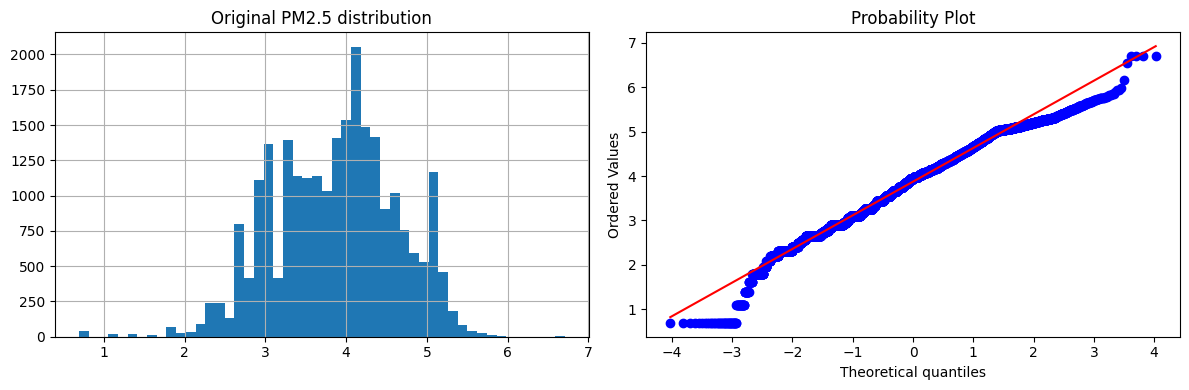

In [176]:
#Handle the target skewness by applying a log transform


print(f"Skewness: {y_tr.skew():.2f}")



# Apply log transform
y_tr_log  = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr_log.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
stats.probplot(y_tr_log, plot=axes[1])
plt.tight_layout()
plt.show()


In [177]:
# Use XGBRegressor to fit the train set and calculate feature importances

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr_log)

xgb_importance = pd.Series(xgb.feature_importances_, index=X_tr.columns)
xgb_importance = xgb_importance.sort_values(ascending=False)

print("Top 100 features by XGBoost:")
print(xgb_importance.head(140))



Top 100 features by XGBoost:
L3_CO_CO_column_number_density_place_roll_8_with_current                     0.067380
L3_HCHO_tropospheric_HCHO_column_number_density_place_roll_8_with_current    0.063373
L3_AER_AI_sensor_altitude_place_roll_8_with_current                          0.060647
wind_speed_10m_above_ground                                                  0.039512
solar_latitude_mean                                                          0.034809
                                                                               ...   
L3_CLOUD_sensor_azimuth_angle                                                0.001630
L3_HCHO_solar_zenith_angle                                                   0.001621
L3_HCHO_cloud_fraction                                                       0.001606
L3_SO2_absorbing_aerosol_index                                               0.001597
L3_SO2_cloud_fraction                                                        0.001553
Length: 140, dtype: float

In [178]:
# Save the top 100 rolling features so other notebooks can reuse the same selection.
top_100_features_df = (
    xgb_importance
    .head(100)
    .rename("xgb_feature_importance")
    .reset_index()
)
top_100_features_df.columns = ["feature", "xgb_feature_importance"]
top_100_features_df.insert(0, "rank", np.arange(1, len(top_100_features_df) + 1))

top_100_features_path = "data/xgboost_rolling_top_100_features.csv"
top_100_features_df.to_csv(top_100_features_path, index=False)
top_100_features = top_100_features_df["feature"].tolist()

print(f"Saved {len(top_100_features_df)} features to {top_100_features_path}")
top_100_features_df.head(10)


Saved 100 features to data/xgboost_rolling_top_100_features.csv


,rank,feature,xgb_feature_importance
0,1,L3_CO_CO_column_number_density_place_roll_8_wi...,0.067380
1,2,L3_HCHO_tropospheric_HCHO_column_number_densit...,0.063373
2,3,L3_AER_AI_sensor_altitude_place_roll_8_with_cu...,0.060647
3,4,wind_speed_10m_above_ground,0.039512
4,5,solar_latitude_mean,0.034809
5,6,L3_CO_CO_column_number_density_place_roll_4_wi...,0.031237
6,7,L3_NO2_NO2_slant_column_number_density_place_r...,0.028827
7,8,wind_speed_10m_above_ground_place_roll_4_with_...,0.024833
8,9,L3_HCHO_HCHO_slant_column_number_density_place...,0.024048
9,10,relative_longitude,0.017961


In [179]:
print(xgb_importance.head(20))

L3_CO_CO_column_number_density_place_roll_8_with_current                     0.067380
L3_HCHO_tropospheric_HCHO_column_number_density_place_roll_8_with_current    0.063373
L3_AER_AI_sensor_altitude_place_roll_8_with_current                          0.060647
wind_speed_10m_above_ground                                                  0.039512
solar_latitude_mean                                                          0.034809
L3_CO_CO_column_number_density_place_roll_4_with_current                     0.031237
L3_NO2_NO2_slant_column_number_density_place_roll_4_with_current             0.028827
wind_speed_10m_above_ground_place_roll_4_with_current                        0.024833
L3_HCHO_HCHO_slant_column_number_density_place_roll_8_with_current           0.024048
relative_longitude                                                           0.017961
temperature_2m_above_ground_place_roll_8_with_current                        0.015936
L3_CLOUD_cloud_optical_depth_place_roll_8_with_current

In [180]:
# Predict and reverse log transform
y_val_pred_xgb = np.expm1(xgb.predict(X_val))

# Compute RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
print(f"XGBoost Validation RMSE: {rmse_xgb:.2f} µg/m³")

XGBoost Validation RMSE: 27.08 µg/m³


In [181]:
print(f"Random Forest RMSE: 32.03 µg/m³")
print(f"XGBoost RMSE:       {rmse_xgb:.2f} µg/m³")
print(f"Difference:         {32.03 - rmse_xgb:.2f} µg/m³")


Random Forest RMSE: 32.03 µg/m³
XGBoost RMSE:       27.08 µg/m³
Difference:         4.95 µg/m³


## Tuned XGBoost Prediction

Use the best hyperparameters from the previous RandomizedSearchCV run without rerunning the search.

In [182]:
# Use saved best hyperparameters from the previous top-100-feature search.
top_100_features = xgb_importance.head(100).index.tolist()

X_tr_top_100 = X_tr[top_100_features]
X_val_top_100 = X_val[top_100_features]

best_xgb_params = {
    'subsample': 0.8,
    'n_estimators': 370,
    'min_child_weight': 2,
    'max_depth': 10,
    'learning_rate': 0.03,
    'colsample_bytree': 0.6,
}

best_xgb = XGBRegressor(
    **best_xgb_params,
    random_state=42,
    n_jobs=-1,
)

best_xgb.fit(X_tr_top_100, y_tr_log)
y_val_pred = np.expm1(best_xgb.predict(X_val_top_100))
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Tuned XGBoost RMSE with top 100 features: {rmse:.2f} µg/m³")
print("Best params:", best_xgb_params)


Tuned XGBoost RMSE with top 100 features: 25.54 µg/m³
Best params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 2, 'max_depth': 10, 'learning_rate': 0.04, 'colsample_bytree': 0.4}


In [ ]:
# Hyperparameter optimization with grouped CV by Place_ID.
# The scorer reverses the log target so CV RMSE is measured in the original target unit.
RUN_GROUPED_CV_XGB_SEARCH = False
N_CV_SEARCH_FEATURES = 90
N_CV_SPLITS = 5
N_SEARCH_ITER = 30

def original_scale_rmse(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))

original_scale_rmse_scorer = make_scorer(
    original_scale_rmse,
    greater_is_better=False,
)

if RUN_GROUPED_CV_XGB_SEARCH:
    top_cv_search_features = xgb_importance.head(N_CV_SEARCH_FEATURES).index.tolist()
    X_tr_cv_search = X_tr[top_cv_search_features]
    X_val_cv_search = X_val[top_cv_search_features]
    groups = train_meta["Place_ID"].reset_index(drop=True)

    param_grid = {
        "n_estimators": [320,350,370],
        "max_depth": [10,11,12],
        "learning_rate": [0.03,0.04],
        "subsample": [0.8,0.9],
        "colsample_bytree": [0.4,0.5,0.6],
        "min_child_weight": [2],
    }

    group_cv = GroupKFold(n_splits=N_CV_SPLITS)
    xgb_cv = XGBRegressor(random_state=42, n_jobs=-1)

    grouped_cv_search = RandomizedSearchCV(
        estimator=xgb_cv,
        param_distributions=param_grid,
        n_iter=N_SEARCH_ITER,
        scoring=original_scale_rmse_scorer,
        cv=group_cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )

    grouped_cv_search.fit(X_tr_cv_search, y_tr_log, groups=groups)

    grouped_cv_best_xgb = grouped_cv_search.best_estimator_
    grouped_cv_y_val_pred = np.expm1(grouped_cv_best_xgb.predict(X_val_cv_search))
    grouped_cv_val_rmse = np.sqrt(mean_squared_error(y_val, grouped_cv_y_val_pred))

    print("Best grouped-CV XGBoost params:")
    print(grouped_cv_search.best_params_)
    print(f"Best grouped-CV mean RMSE: {-grouped_cv_search.best_score_:.2f} µg/m³")
    print(f"Clean validation RMSE with grouped-CV params: {grouped_cv_val_rmse:.2f} µg/m³")
else:
    print("Skipping grouped CV hyperparameter search.")


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/christinck/Desktop/week-9/air_pollution_mlproject/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best grouped-CV XGBoost params:
{'subsample': 0.8, 'n_estimators': 370, 'min_child_weight': 2, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Best grouped-CV mean RMSE: 31.66 µg/m³
Clean validation RMSE with grouped-CV params: 25.46 µg/m³


In [184]:
# Hyperparameter tuning on XGBoost using only the top 100 features from the previous XGBoost importance ranking.
# Keep this False unless you explicitly want to rerun the expensive search.
RUN_XGB_HYPERPARAMETER_SEARCH = False

if RUN_XGB_HYPERPARAMETER_SEARCH:
    top_100_features = xgb_importance.head(100).index.tolist()

    X_tr_top_100 = X_tr[top_100_features]
    X_val_top_100 = X_val[top_100_features]

    print(f"Using {len(top_100_features)} features for hyperparameter tuning")

    param_grid = {
        'n_estimators':     [250,300,350],
        'max_depth':        [9,11],
        'learning_rate':    [0.04, 0.05, 0.07],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.4,0.6, 0.8,],
        'min_child_weight': [1, 2]
    }

    xgb = XGBRegressor(random_state=42, n_jobs=-1)
    search = RandomizedSearchCV(
        xgb,
        param_grid,
        n_iter=30,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_tr_top_100, y_tr_log)

    print("Best params:", search.best_params_)
    print("Best CV RMSE:", -search.best_score_)
else:
    print("Skipping XGBoost hyperparameter search. Using best_xgb_params above.")


Skipping XGBoost hyperparameter search. Using best_xgb_params above.


In [185]:
# Optional: evaluate the model returned by RandomizedSearchCV if you reran the search.
if "search" in globals() and hasattr(search, "best_estimator_"):
    search_best_xgb = search.best_estimator_
    search_y_val_pred = np.expm1(search_best_xgb.predict(X_val_top_100))
    search_rmse = np.sqrt(mean_squared_error(y_val, search_y_val_pred))
    print(f"Search-tuned XGBoost RMSE with top 100 features: {search_rmse:.2f} µg/m³")
    print(f"Fixed tuned XGBoost RMSE: {rmse:.2f} µg/m³")
else:
    print("RandomizedSearchCV was not run in this session.")


RandomizedSearchCV was not run in this session.


## Rolling XGBoost Model Comparison


                               Model      RMSE
XGBoost rolling - fixed tuned params 25.542290
           XGBoost rolling - default 27.078192
XGBoost non-rolling - tuned baseline 28.069933


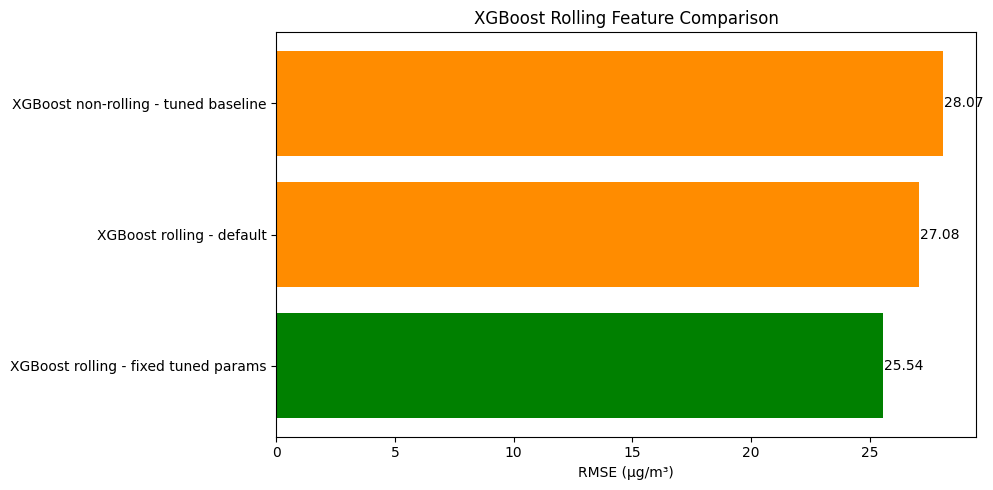

,Model,RMSE
0,XGBoost rolling - fixed tuned params,25.542290
1,XGBoost rolling - default,27.078192
2,XGBoost non-rolling - tuned baseline,28.069933


In [186]:
# Compare non-rolling tuned XGBoost against rolling default and rolling tuned models.
# The non-rolling baseline is rebuilt here so this notebook does not depend on variables from XGBoost.ipynb.
metadata_cols = ["Place_ID", "Date", "Place_ID X Date"]
baseline_drop_cols = ["target"] + [col for col in metadata_cols if col in clean_train.columns]

X_tr_nonrolling = clean_train.drop(columns=baseline_drop_cols)
X_val_nonrolling = clean_val.drop(columns=baseline_drop_cols)

# Recreate the tuned non-rolling baseline from the regular XGBoost notebook style.
xgb_nonrolling_selector = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
xgb_nonrolling_selector.fit(X_tr_nonrolling, y_tr_log)

nonrolling_importance = pd.Series(
    xgb_nonrolling_selector.feature_importances_,
    index=X_tr_nonrolling.columns,
).sort_values(ascending=False)
nonrolling_top_features = nonrolling_importance.head(25).index.tolist()

xgb_nonrolling_tuned = XGBRegressor(
    **best_xgb_params,
    random_state=42,
    n_jobs=-1,
)
xgb_nonrolling_tuned.fit(X_tr_nonrolling[nonrolling_top_features], y_tr_log)

y_val_pred_nonrolling_tuned = np.expm1(
    xgb_nonrolling_tuned.predict(X_val_nonrolling[nonrolling_top_features])
)
rmse_nonrolling_tuned = np.sqrt(mean_squared_error(y_val, y_val_pred_nonrolling_tuned))

# Use the fixed tuned rolling model from above: this is the run with RMSE around 26.50.
rolling_tuned_label = "XGBoost rolling - fixed tuned params"
rolling_tuned_rmse = rmse
rolling_tuned_pred = y_val_pred

xgb_rolling_results = pd.DataFrame({
    "Model": [
        "XGBoost non-rolling - tuned baseline",
        "XGBoost rolling - default",
        rolling_tuned_label,
    ],
    "RMSE": [
        rmse_nonrolling_tuned,
        rmse_xgb,
        rolling_tuned_rmse,
    ],
})

xgb_rolling_results = xgb_rolling_results.sort_values("RMSE").reset_index(drop=True)

print(xgb_rolling_results.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ["green" if value == xgb_rolling_results["RMSE"].min() else "darkorange" for value in xgb_rolling_results["RMSE"]]
plt.barh(xgb_rolling_results["Model"], xgb_rolling_results["RMSE"], color=colors)
plt.xlabel("RMSE (µg/m³)")
plt.title("XGBoost Rolling Feature Comparison")
for i, value in enumerate(xgb_rolling_results["RMSE"]):
    plt.text(value + 0.05, i, f"{value:.2f}", va="center")
plt.tight_layout()
plt.show()

xgb_rolling_predictions = {
    "XGBoost non-rolling - tuned baseline": y_val_pred_nonrolling_tuned,
    "XGBoost rolling - default": y_val_pred_xgb,
    rolling_tuned_label: rolling_tuned_pred,
}

xgb_rolling_results


## Rolling XGBoost Diagnostics


# Residual analysis for the fixed tuned rolling model, the run with RMSE around 26.50.
best_model_name = "XGBoost rolling - fixed tuned params"
best_prediction = pd.Series(y_val_pred, index=y_val.index)
residuals = y_val - best_prediction

plt.figure(figsize=(7, 7))
plt.scatter(y_val, best_prediction, alpha=0.3, color="darkorange")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "b--")
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"XGBoost Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(best_prediction, residuals, alpha=0.3, color="darkorange")
plt.axhline(0, color="blue", linestyle="--")
plt.xlabel("Predicted PM2.5 (µg/m³)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"XGBoost Residuals - {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
residuals.hist(bins=50, color="darkorange")
plt.axvline(0, color="blue", linestyle="--")
plt.xlabel("Residual (µg/m³)")
plt.title(f"XGBoost Residual Distribution - {best_model_name}")
plt.tight_layout()
plt.show()


Average residual for XGBoost rolling - fixed tuned params: 4.79 µg/m³


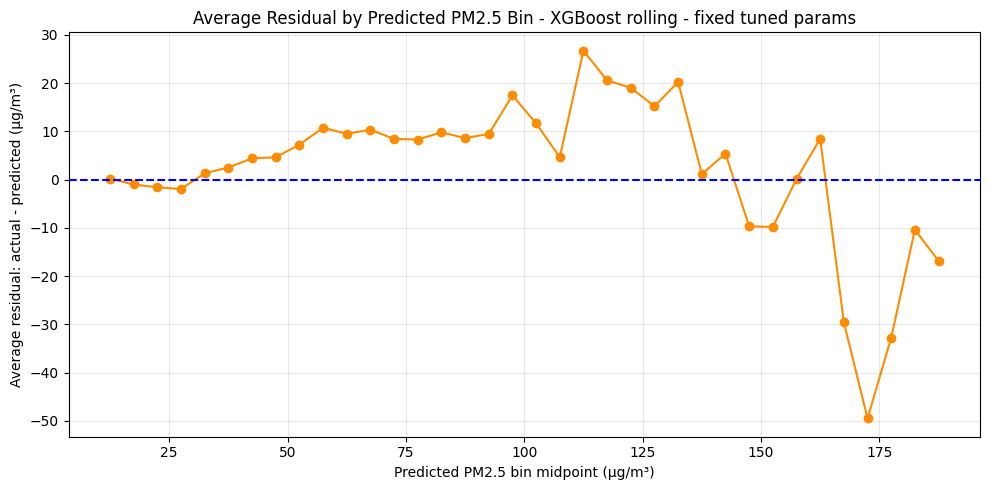

In [187]:
# Average residual for the fixed tuned rolling model.
# Positive means the model underpredicted on average.
prediction_for_residuals = pd.Series(y_val_pred, index=y_val.index)
model_name = "XGBoost rolling - fixed tuned params"

residuals = y_val - prediction_for_residuals
average_residual = residuals.mean()
print(f"Average residual for {model_name}: {average_residual:.2f} µg/m³")

# Plot average residual by predicted PM2.5 bins of 5 µg/m³.
residual_df = pd.DataFrame({
    "predicted_pm25": prediction_for_residuals,
    "residual": residuals,
})

bin_width = 5
bin_start = np.floor(residual_df["predicted_pm25"].min() / bin_width) * bin_width
bin_end = np.ceil(residual_df["predicted_pm25"].max() / bin_width) * bin_width + bin_width
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

residual_df["predicted_bin"] = pd.cut(
    residual_df["predicted_pm25"],
    bins=bins,
    right=False,
)

residual_by_bin = (
    residual_df
    .groupby("predicted_bin", observed=True)
    .agg(
        average_residual=("residual", "mean"),
        count=("residual", "size"),
    )
    .reset_index()
)
residual_by_bin["bin_midpoint"] = residual_by_bin["predicted_bin"].apply(lambda interval: interval.mid)

plt.figure(figsize=(10, 5))
plt.plot(
    residual_by_bin["bin_midpoint"],
    residual_by_bin["average_residual"],
    marker="o",
    color="darkorange",
)
plt.axhline(0, color="blue", linestyle="--")
plt.xlabel("Predicted PM2.5 bin midpoint (µg/m³)")
plt.ylabel("Average residual: actual - predicted (µg/m³)")
plt.title(f"Average Residual by Predicted PM2.5 Bin - {model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Out-of-Fold Residual Calibration


Fold 1 OOF RMSE: 33.38 µg/m³
Fold 2 OOF RMSE: 30.49 µg/m³
Fold 3 OOF RMSE: 27.82 µg/m³
Fold 4 OOF RMSE: 38.91 µg/m³
Fold 5 OOF RMSE: 27.45 µg/m³

OOF RMSE before calibration: 31.89 µg/m³

Clean validation RMSE before calibration: 25.54 µg/m³
Clean validation RMSE after calibration:  24.84 µg/m³
Clean validation MAE before calibration:  16.18 µg/m³
Clean validation MAE after calibration:   16.61 µg/m³
Clean validation R2 before calibration:   0.628
Clean validation R2 after calibration:    0.648
RMSE change: 0.70 µg/m³


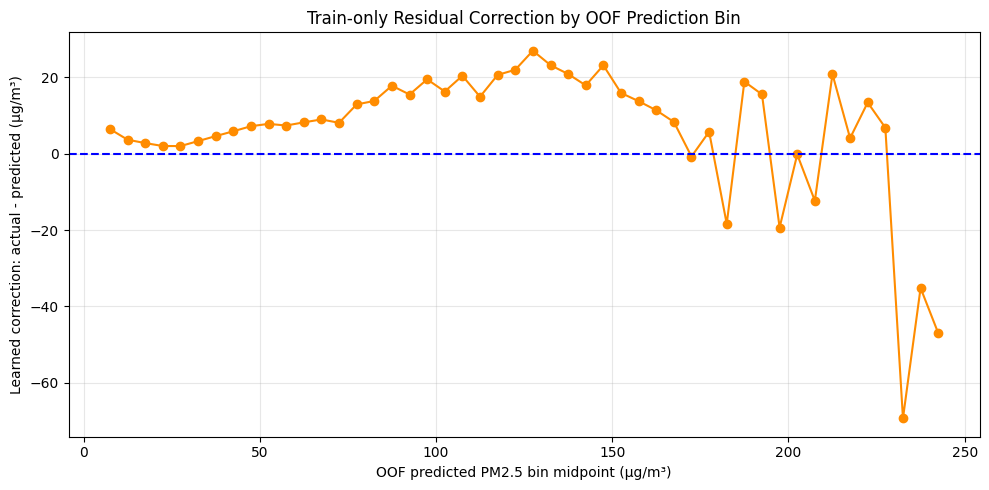

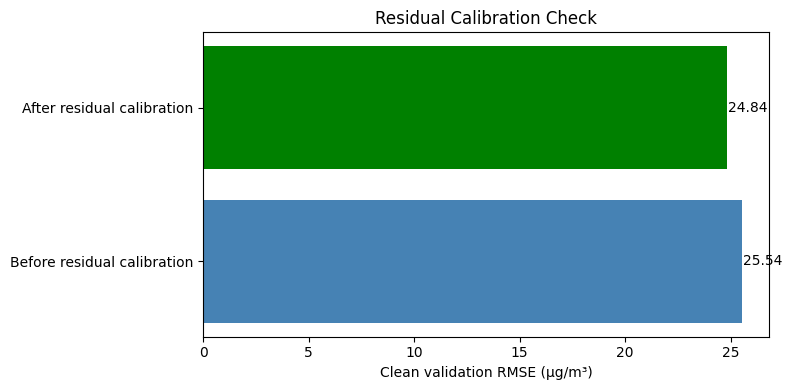

,predicted_bin,correction,count,bin_midpoint
0,"[5.0, 10.0)",6.483041,11,7.5
1,"[10.0, 15.0)",3.695253,190,12.5
2,"[15.0, 20.0)",2.810049,981,17.5
3,"[20.0, 25.0)",2.043742,1964,22.5
4,"[25.0, 30.0)",2.024966,2268,27.5
5,"[30.0, 35.0)",3.322253,2354,32.5
6,"[35.0, 40.0)",4.636068,2213,37.5
7,"[40.0, 45.0)",5.904282,1927,42.5
8,"[45.0, 50.0)",7.229610,1783,47.5
9,"[50.0, 55.0)",7.845356,1633,52.5


In [188]:
# Learn a residual correction from clean_train only, then apply it to the fixed tuned rolling model.
# Set this to True when you want to run the expensive out-of-fold calibration.
RUN_OUT_OF_FOLD_RESIDUAL_CALIBRATION = True
CALIBRATION_BIN_WIDTH = 5
CALIBRATION_N_SPLITS = 5

if RUN_OUT_OF_FOLD_RESIDUAL_CALIBRATION:
    groups = train_meta["Place_ID"].reset_index(drop=True)
    group_cv = GroupKFold(n_splits=CALIBRATION_N_SPLITS)

    oof_pred = pd.Series(index=y_tr.index, dtype=float)

    for fold, (train_idx, val_idx) in enumerate(group_cv.split(X_tr, y_tr, groups=groups), start=1):
        fold_model = XGBRegressor(
            **best_xgb_params,
            random_state=42,
            n_jobs=-1,
        )
        fold_model.fit(X_tr.iloc[train_idx][top_100_features], y_tr_log.iloc[train_idx])

        oof_pred.iloc[val_idx] = np.expm1(
            fold_model.predict(X_tr.iloc[val_idx][top_100_features])
        )
        fold_rmse = np.sqrt(mean_squared_error(y_tr.iloc[val_idx], oof_pred.iloc[val_idx]))
        print(f"Fold {fold} OOF RMSE: {fold_rmse:.2f} µg/m³")

    oof_residuals = y_tr - oof_pred
    print(f"\nOOF RMSE before calibration: {np.sqrt(mean_squared_error(y_tr, oof_pred)):.2f} µg/m³")

    calibration_df = pd.DataFrame({
        "predicted_pm25": oof_pred,
        "residual": oof_residuals,
    }).dropna()

    bin_start = np.floor(calibration_df["predicted_pm25"].min() / CALIBRATION_BIN_WIDTH) * CALIBRATION_BIN_WIDTH
    bin_end = np.ceil(calibration_df["predicted_pm25"].max() / CALIBRATION_BIN_WIDTH) * CALIBRATION_BIN_WIDTH + CALIBRATION_BIN_WIDTH
    calibration_bins = np.arange(bin_start, bin_end + CALIBRATION_BIN_WIDTH, CALIBRATION_BIN_WIDTH)

    calibration_df["predicted_bin"] = pd.cut(
        calibration_df["predicted_pm25"],
        bins=calibration_bins,
        right=False,
    )

    residual_correction_by_bin = (
        calibration_df
        .groupby("predicted_bin", observed=True)
        .agg(
            correction=("residual", "mean"),
            count=("residual", "size"),
        )
        .reset_index()
    )
    residual_correction_by_bin["bin_midpoint"] = residual_correction_by_bin["predicted_bin"].apply(lambda interval: interval.mid).astype(float)

    # Interpolate the binned correction so every prediction receives a correction.
    correction_x = residual_correction_by_bin["bin_midpoint"].to_numpy()
    correction_y = residual_correction_by_bin["correction"].to_numpy()

    val_correction = np.interp(
        y_val_pred,
        correction_x,
        correction_y,
        left=correction_y[0],
        right=correction_y[-1],
    )

    y_val_pred_calibrated = np.clip(y_val_pred + val_correction, a_min=0, a_max=None)
    rmse_before_calibration = np.sqrt(mean_squared_error(y_val, y_val_pred))
    rmse_after_calibration = np.sqrt(mean_squared_error(y_val, y_val_pred_calibrated))
    mae_before_calibration = mean_absolute_error(y_val, y_val_pred)
    mae_after_calibration = mean_absolute_error(y_val, y_val_pred_calibrated)
    r2_before_calibration = r2_score(y_val, y_val_pred)
    r2_after_calibration = r2_score(y_val, y_val_pred_calibrated)

    print(f"\nClean validation RMSE before calibration: {rmse_before_calibration:.2f} µg/m³")
    print(f"Clean validation RMSE after calibration:  {rmse_after_calibration:.2f} µg/m³")
    print(f"Clean validation MAE before calibration:  {mae_before_calibration:.2f} µg/m³")
    print(f"Clean validation MAE after calibration:   {mae_after_calibration:.2f} µg/m³")
    print(f"Clean validation R2 before calibration:   {r2_before_calibration:.3f}")
    print(f"Clean validation R2 after calibration:    {r2_after_calibration:.3f}")
    print(f"RMSE change: {rmse_before_calibration - rmse_after_calibration:.2f} µg/m³")

    plt.figure(figsize=(10, 5))
    plt.plot(
        residual_correction_by_bin["bin_midpoint"],
        residual_correction_by_bin["correction"],
        marker="o",
        color="darkorange",
    )
    plt.axhline(0, color="blue", linestyle="--")
    plt.xlabel("OOF predicted PM2.5 bin midpoint (µg/m³)")
    plt.ylabel("Learned correction: actual - predicted (µg/m³)")
    plt.title("Train-only Residual Correction by OOF Prediction Bin")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    calibration_results = pd.DataFrame({
        "Model": ["Before residual calibration", "After residual calibration"],
        "RMSE": [rmse_before_calibration, rmse_after_calibration],
        "MAE": [mae_before_calibration, mae_after_calibration],
        "R2": [r2_before_calibration, r2_after_calibration],
    })

    plt.figure(figsize=(8, 4))
    colors = ["steelblue", "green" if rmse_after_calibration < rmse_before_calibration else "darkorange"]
    plt.barh(calibration_results["Model"], calibration_results["RMSE"], color=colors)
    plt.xlabel("Clean validation RMSE (µg/m³)")
    plt.title("Residual Calibration Check")
    for i, value in enumerate(calibration_results["RMSE"]):
        plt.text(value + 0.05, i, f"{value:.2f}", va="center")
    plt.tight_layout()
    plt.show()

    display(residual_correction_by_bin)
else:
    print("Skipping out-of-fold residual calibration. Set RUN_OUT_OF_FOLD_RESIDUAL_CALIBRATION = True to run it.")


## Zindi Test Submission

Train the same tuned rolling XGBoost pipeline on all labeled cleaned data, learn the residual correction from out-of-fold training predictions, predict `clean_test.csv`, and save a Zindi-formatted submission file.

In [189]:
# Final Zindi submission using the rolling XGBoost + residual correction pipeline.
# Set this to True when you want to regenerate the submission file.
RUN_ZINDI_TEST_SUBMISSION = False

if RUN_ZINDI_TEST_SUBMISSION:
    clean_test = pd.read_csv("data/clean_test.csv")
    sample_submission = pd.read_csv("data/SampleSubmission.csv")

    full_clean_train = pd.concat([clean_train, clean_val], axis=0, ignore_index=True)

    metadata_cols = ["Place_ID", "Date", "Place_ID X Date"]
    full_meta = full_clean_train[["Place_ID", "Date"]].copy()
    test_meta = clean_test[["Place_ID", "Date"]].copy()

    full_drop_cols = ["target"] + [col for col in metadata_cols if col in full_clean_train.columns]
    test_drop_cols = [col for col in metadata_cols if col in clean_test.columns]

    X_full = full_clean_train.drop(columns=full_drop_cols)
    y_full = full_clean_train["target"]
    X_test = clean_test.drop(columns=test_drop_cols).reindex(columns=X_full.columns)
    y_full_log = np.log1p(y_full.reset_index(drop=True))

    full_meta["Date"] = pd.to_datetime(full_meta["Date"])
    test_meta["Date"] = pd.to_datetime(test_meta["Date"])

    def add_current_day_rolling_features_fast(X, meta, windows, exclude_cols=None):
        exclude_cols = set(exclude_cols or [])
        X = X.reset_index(drop=True).copy()
        meta = meta.reset_index(drop=True).copy()
        df = pd.concat([meta, X], axis=1).sort_values(["Place_ID", "Date"])
        rolling_source_cols = [col for col in X.columns if col not in exclude_cols]

        rolling_frames = []
        for window in windows:
            rolled = (
                df.groupby("Place_ID")[rolling_source_cols]
                .rolling(window, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )
            rolled.columns = [f"{col}_place_roll_{window}_with_current" for col in rolled.columns]
            rolling_frames.append(rolled)

        rolling_df = pd.concat(rolling_frames, axis=1).sort_index().reset_index(drop=True)
        return pd.concat([X, rolling_df], axis=1)

    print("Submission rolling windows:", ROLLING_WINDOWS)
    print("Columns excluded from rolling:", [col for col in ROLLING_EXCLUDE_COLS if col in X_full.columns])
    print("Submission XGBoost hyperparameters:", best_xgb_params)

    X_full_rolling = add_current_day_rolling_features_fast(
        X_full,
        full_meta,
        ROLLING_WINDOWS,
        exclude_cols=ROLLING_EXCLUDE_COLS,
    )
    X_test_rolling = add_current_day_rolling_features_fast(
        X_test,
        test_meta,
        ROLLING_WINDOWS,
        exclude_cols=ROLLING_EXCLUDE_COLS,
    )
    X_test_rolling = X_test_rolling.reindex(columns=X_full_rolling.columns)
    print("X_full_rolling shape:", X_full_rolling.shape)
    print("X_test_rolling shape:", X_test_rolling.shape)

    # Select the top 100 rolling features on all labeled data.
    submission_selector = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    submission_selector.fit(X_full_rolling, y_full_log)
    submission_importance = pd.Series(
        submission_selector.feature_importances_,
        index=X_full_rolling.columns,
    ).sort_values(ascending=False)
    submission_top_100_features = submission_importance.head(100).index.tolist()

    print(f"Selected submission features: {len(submission_top_100_features)}")
    submission_feature_table = (
        submission_importance
        .head(100)
        .rename("xgb_importance")
        .reset_index()
    )
    submission_feature_table.columns = ["feature", "xgb_importance"]
    print(submission_feature_table.to_string(index=False))

    # Fit final tuned model on all labeled data.
    submission_xgb = XGBRegressor(
        **best_xgb_params,
        random_state=42,
        n_jobs=-1,
    )
    submission_xgb.fit(X_full_rolling[submission_top_100_features], y_full_log)
    test_pred = np.expm1(
        submission_xgb.predict(X_test_rolling[submission_top_100_features])
    )

    # Learn residual correction from out-of-fold predictions on all labeled data.
    groups = full_meta["Place_ID"].reset_index(drop=True)
    group_cv = GroupKFold(n_splits=CALIBRATION_N_SPLITS)
    oof_pred_submission = pd.Series(index=y_full.index, dtype=float)

    for fold, (train_idx, val_idx) in enumerate(group_cv.split(X_full_rolling, y_full, groups=groups), start=1):
        fold_model = XGBRegressor(
            **best_xgb_params,
            random_state=42,
            n_jobs=-1,
        )
        fold_model.fit(
            X_full_rolling.iloc[train_idx][submission_top_100_features],
            y_full_log.iloc[train_idx],
        )
        oof_pred_submission.iloc[val_idx] = np.expm1(
            fold_model.predict(X_full_rolling.iloc[val_idx][submission_top_100_features])
        )
        fold_rmse = np.sqrt(mean_squared_error(y_full.iloc[val_idx], oof_pred_submission.iloc[val_idx]))
        print(f"Submission calibration fold {fold} OOF RMSE: {fold_rmse:.2f} µg/m³")

    submission_calibration_df = pd.DataFrame({
        "predicted_pm25": oof_pred_submission,
        "residual": y_full - oof_pred_submission,
    }).dropna()

    bin_start = np.floor(submission_calibration_df["predicted_pm25"].min() / CALIBRATION_BIN_WIDTH) * CALIBRATION_BIN_WIDTH
    bin_end = np.ceil(submission_calibration_df["predicted_pm25"].max() / CALIBRATION_BIN_WIDTH) * CALIBRATION_BIN_WIDTH + CALIBRATION_BIN_WIDTH
    submission_calibration_bins = np.arange(bin_start, bin_end + CALIBRATION_BIN_WIDTH, CALIBRATION_BIN_WIDTH)

    submission_calibration_df["predicted_bin"] = pd.cut(
        submission_calibration_df["predicted_pm25"],
        bins=submission_calibration_bins,
        right=False,
    )

    submission_correction_by_bin = (
        submission_calibration_df
        .groupby("predicted_bin", observed=True)
        .agg(correction=("residual", "mean"), count=("residual", "size"))
        .reset_index()
    )
    submission_correction_by_bin["bin_midpoint"] = (
        submission_correction_by_bin["predicted_bin"]
        .apply(lambda interval: interval.mid)
        .astype(float)
    )

    correction_x = submission_correction_by_bin["bin_midpoint"].to_numpy()
    correction_y = submission_correction_by_bin["correction"].to_numpy()
    test_correction = np.interp(
        test_pred,
        correction_x,
        correction_y,
        left=correction_y[0],
        right=correction_y[-1],
    )

    test_pred_calibrated = np.clip(test_pred + test_correction, a_min=0, a_max=None)

    submission = sample_submission.copy()
    submission["target"] = test_pred_calibrated
    submission.to_csv("data/xgboost_rolling_new_features_groupedcv_residual_submission.csv", index=False)

    print("Saved data/xgboost_rolling_submission.csv", submission.shape)
    display(submission.head())
else:
    print("Skipping Zindi test submission. Set RUN_ZINDI_TEST_SUBMISSION = True to regenerate it.")


Skipping Zindi test submission. Set RUN_ZINDI_TEST_SUBMISSION = True to regenerate it.
